# Sentinel-1 Filtering — DE-Har 2025

## Data source

Uses the `sentle` weekly-composite zarr:
`/mnt/data/lk1167/projects/other/data/icos-har/processed/sentinel/sentinel_har_2025.zarr`

**Why this, not the NC files from `process_sentinel1.py`?**
The zarr uses `sentle`'s weekly compositing pipeline: all available S1 passes
within each 7-day window are averaged before storage.  This single step
simultaneously (a) reduces speckle (ENL raised by number of passes averaged),
(b) removes the two-track angle-bias zigzag that affects the raw individual-pass
NC files from 2025 onward (when S1C joined S1A), and (c) provides a regular
weekly time axis.  The raw GEE NC files do not apply these corrections.

Bands stored: `vh_desc`, `vv_desc` (descending, pre-dawn — preferred orbit
direction for Central Europe), plus ascending and Sentinel-2 bands.
Data are in **linear (power) scale** — all indices are computed in linear
and only converted to dB for display / CSV output.

## Processing chain

```
zarr (linear, weekly composites)
 → select descending VH + VV
 → crop to ROI region
 → [opt.] Lee speckle filter per scene  (in linear scale)
 → [opt.] Savitzky-Golay temporal filter  (pixel-wise, in linear scale)
 → derive indices  (CR = VV/VH, RVI, Span)
 → ROI circle extraction  (100 m buffer around tower, 313 pixels)
 → mean ± std across pixels → CSV + plots
```

In [298]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import ndimage
from scipy.signal import savgol_filter
from pathlib import Path

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'axes.grid':        True,
    'grid.alpha':       0.3,
    'font.size':        11,
})

PROJECT_ROOT = Path().resolve().parents[1]
OUT_CSV      = PROJECT_ROOT / 'data/processed/satellite/sentinel1_filtered_2025.csv'

## Parameters

In [299]:
ZARR_PATH = Path('/mnt/data/lk1167/projects/other/data/icos-har/processed/sentinel/sentinel_har_2025.zarr')

# ── ROI — field site bounding box (matches reference notebook) ────────────────
SITE_LEFT   = 395304.3125
SITE_BOTTOM = 5309842.5
SITE_RIGHT  = 395373.5
SITE_TOP    = 5309912.5

# ── Lee speckle filter ─────────────────────────────────────────────────────────
LEE_KERNEL = 1       # 3×3, scene-wide variance estimator (matches reference)

# ── Temporal filters ───────────────────────────────────────────────────────────
# Applied in order: rolling mean on 3-D xarray → aggregate to 1-D → Savitzky-Golay
ROLLING_WINDOW = 3   # time steps (~21 days for weekly composites)
SAVGOL_WINDOW  = 5   # must be odd; applied on aggregated 1-D time series
SAVGOL_POLY    = 2

## Helper functions

In [300]:
def lin2db(x):
    x = np.asarray(x, dtype=np.float64)
    return 10.0 * np.log10(np.where(x > 0, x, np.nan))


def lee_filter(img: np.ndarray, size: int = 3) -> np.ndarray:
    """Lee speckle filter — scene-wide variance estimator (matches reference).

    Uses scipy.ndimage.variance(img) as the noise variance estimate rather than
    the local CV² approach, which is identical to what the reference notebook does.
    """
    img_mean     = ndimage.uniform_filter(img, size=(size, size))
    img_sqr_mean = ndimage.uniform_filter(img ** 2, size=(size, size))
    img_variance = img_sqr_mean - img_mean ** 2
    overall_var  = float(ndimage.variance(img))
    weights      = img_variance / (img_variance + overall_var + 1e-30)
    return img_mean + weights * (img - img_mean)


def apply_lee(da: xr.DataArray, size: int = 3) -> xr.DataArray:
    """Apply Lee filter frame-by-frame to a (time, y, x) DataArray."""
    out = da.copy()
    for t in range(len(da.time)):
        out.values[t] = lee_filter(da.values[t], size=size)
    return out

## Load data

In [301]:
print(f'Loading: {ZARR_PATH}')
ds_z = xr.open_zarr(ZARR_PATH, chunks={})
da   = ds_z['sentle']

x_coords = ds_z.x.values
y_coords = ds_z.y.values
times    = pd.to_datetime(sorted(ds_z.time.values))

print(f'Grid: {len(x_coords)}×{len(y_coords)} px @ {x_coords[1]-x_coords[0]:.0f} m')
print(f'Scenes: {len(times)},  {times[0].date()} – {times[-1].date()}')
print(f'Bands: {list(ds_z.band.values)}')

# Keep in LINEAR scale — all processing (Lee, rolling, indices) must be in linear.
# dB conversion happens only at plot time via lin2db().
vh_da = da.sel(band='vh_desc').sortby('time')
vv_da = da.sel(band='vv_desc').sortby('time')
print(f'\nVH linear: {float(vh_da.mean()):.4f}  →  {lin2db(float(vh_da.mean())):.1f} dB mean')
print(f'VV linear: {float(vv_da.mean()):.4f}  →  {lin2db(float(vv_da.mean())):.1f} dB mean')

Loading: /mnt/data/lk1167/projects/other/data/icos-har/processed/sentinel/sentinel_har_2025.zarr
Grid: 100×100 px @ 10 m
Scenes: 48,  2025-01-02 – 2025-11-27
Bands: ['B01', 'B02', 'B03', 'B04', 'B05', 'B06', 'B07', 'B08', 'B8A', 'B09', 'B11', 'B12', 'vh_asc', 'vh_desc', 'vv_asc', 'vv_desc']

VH linear: 0.0375  →  -14.3 dB mean
VV linear: 0.1330  →  -8.8 dB mean


## Crop to field site

In [304]:
# y is descending in image coordinates → slice from top to bottom
vh_site = vh_da.sel(x=slice(SITE_LEFT, SITE_RIGHT), y=slice(SITE_TOP, SITE_BOTTOM))
vv_site = vv_da.sel(x=slice(SITE_LEFT, SITE_RIGHT), y=slice(SITE_TOP, SITE_BOTTOM))

n_pix = vh_site.shape[1] * vh_site.shape[2]
print(f'Field site crop: {vh_site.shape}  ({n_pix} pixels)')
print(f'X: {float(vh_site.x.min()):.1f} – {float(vh_site.x.max()):.1f} m')
print(f'Y: {float(vh_site.y.min()):.1f} – {float(vh_site.y.max()):.1f} m')

Field site crop: (48, 7, 7)  (49 pixels)
X: 395310.0 – 395370.0 m
Y: 5309850.0 – 5309910.0 m


## Stage 1 — Lee speckle filter  (spatial, linear scale)

In [305]:
vh_loaded = vh_site.load()
vv_loaded = vv_site.load()
print('Data loaded into memory.')

print(f'Applying Lee {LEE_KERNEL}×{LEE_KERNEL} spatial filter ...')
vh_spatial = apply_lee(vh_loaded, size=LEE_KERNEL)
vv_spatial = apply_lee(vv_loaded, size=LEE_KERNEL)
print('  done')

Data loaded into memory.
Applying Lee 1×1 spatial filter ...
  done


## Stage 2 — Rolling mean temporal filter  (3-D, before aggregation)

In [306]:
vh_rolled = vh_spatial.rolling(time=ROLLING_WINDOW, center=True).mean()
vv_rolled = vv_spatial.rolling(time=ROLLING_WINDOW, center=True).mean()

# Drop NaN edges created by the rolling window
vh_rolled = vh_rolled.dropna(dim='time')
vv_rolled = vv_rolled.dropna(dim='time')

print(f'Rolling mean (window={ROLLING_WINDOW}) applied.')
print(f'Time steps: {len(vh_site.time)} → {len(vh_rolled.time)} after dropping NaN edges')

Rolling mean (window=3) applied.
Time steps: 48 → 44 after dropping NaN edges


## Compute indices  (from filtered linear bands)

All indices derived from the filtered linear VH/VV to avoid noise propagation.

In [307]:
cr   = vv_rolled / (vh_rolled)
rvi  = 4 * vh_rolled / (vv_rolled + vh_rolled)
span = vv_rolled + vh_rolled
print('Indices computed (CR, RVI, Span) from Lee + rolling-mean filtered data.')

Indices computed (CR, RVI, Span) from Lee + rolling-mean filtered data.


## Aggregate to time series + Savitzky-Golay

Aggregate all site pixels to a single mean, then apply Savitzky-Golay on the 1-D time series.
This matches the reference notebook: spatial average first, smooth the aggregate second.

In [308]:
time_index = pd.to_datetime(vh_rolled.time.values)

# Aggregate all site pixels → 1-D mean and std time series
ts_rolling = pd.DataFrame({
    'VH':   vh_rolled.mean(dim=['x', 'y']).values,
    'VV':   vv_rolled.mean(dim=['x', 'y']).values,
    'CR':   cr.mean(dim=['x', 'y']).values,
    'RVI':  rvi.mean(dim=['x', 'y']).values,
    'Span': span.mean(dim=['x', 'y']).values,
}, index=time_index).sort_index()

# Spatial SD across ROI pixels — shows within-site heterogeneity
ts_rolling_std = pd.DataFrame({
    'VH':   vh_rolled.std(dim=['x', 'y']).values,
    'VV':   vv_rolled.std(dim=['x', 'y']).values,
    'CR':   cr.std(dim=['x', 'y']).values,
    'RVI':  rvi.std(dim=['x', 'y']).values,
    'Span': span.std(dim=['x', 'y']).values,
}, index=time_index).sort_index()

# Savitzky-Golay on 1-D time series (matches reference)
ts_savgol = ts_rolling.copy()
for col in ts_savgol.columns:
    valid = ~np.isnan(ts_savgol[col])
    if valid.sum() >= SAVGOL_WINDOW:
        ts_savgol.loc[valid, col] = savgol_filter(
            ts_savgol.loc[valid, col].values,
            window_length=SAVGOL_WINDOW,
            polyorder=SAVGOL_POLY,
        )

print(f'{len(ts_rolling)} time steps, {n_pix} pixels')
print(ts_savgol)

44 time steps, 49 pixels
                  VH        VV        CR       RVI      Span
2025-01-09  0.044911  0.143895  3.410965  0.980647  0.188805
2025-01-16  0.041881  0.135029  3.507981  0.951024  0.176910
2025-01-23  0.040747  0.130965  3.535444  0.940381  0.171712
2025-01-30  0.042151  0.134066  3.518390  0.945727  0.176217
2025-02-06  0.042578  0.133287  3.361601  0.970382  0.175866
2025-02-13  0.039897  0.125281  3.347796  0.974127  0.165178
2025-02-20  0.035841  0.116564  3.412487  0.946838  0.152405
2025-02-27  0.036318  0.117479  3.379028  0.958198  0.153797
2025-03-06  0.038376  0.121236  3.278983  0.978471  0.159612
2025-03-13  0.042364  0.132062  3.234748  0.990893  0.174426
2025-03-20  0.043638  0.139692  3.365708  0.966840  0.183329
2025-03-27  0.042121  0.131854  3.278585  1.000412  0.173975
2025-04-03  0.039527  0.119744  3.134609  1.028815  0.159271
2025-04-10  0.037308  0.120917  3.295256  0.976837  0.158224
2025-04-17  0.038733  0.143758  3.766544  0.869264  0.182491

In [285]:
lin2db(ts_savgol['CR'])

array([5.32877289, 5.45057181, 5.48443907, 5.46344   , 5.26546148,
       5.24759012, 5.33070979, 5.28791801, 5.1573918 , 5.09840438,
       5.27076388, 5.15686442, 4.96183407, 5.17889146, 5.7594303 ,
       6.16402413, 6.07326528, 5.95430575, 5.81558407, 5.78714084,
       5.65210226, 5.57988616, 5.65727637, 5.82128431, 6.04377374,
       5.93373049, 5.89912266, 5.98875814, 6.46271022, 6.61417926,
       6.52954452, 6.1162858 , 5.86878433, 5.59405288, 5.45626361,
       5.34249223, 5.36229302, 5.23899326, 5.22103079, 5.21302841,
       5.38616017, 5.42957019, 5.50001571, 5.57296293])

## Plots — raw vs filtered

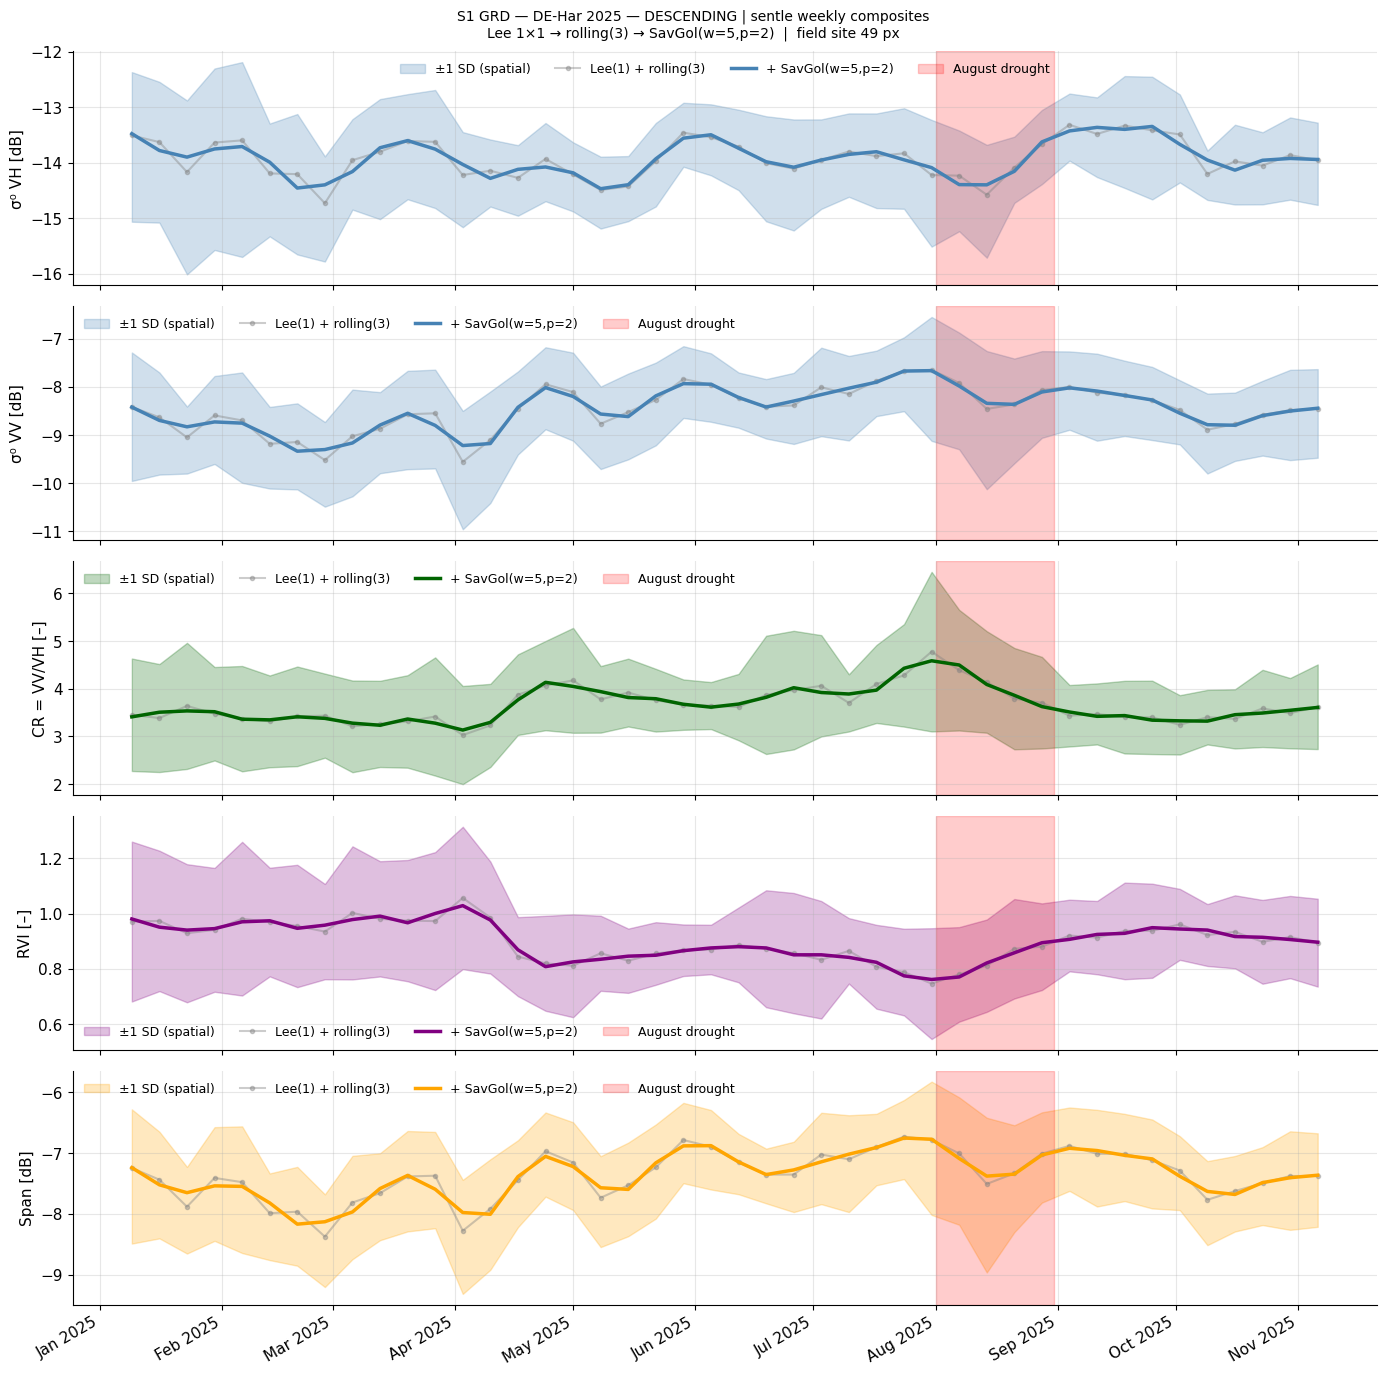

In [309]:
# VH, VV, Span are stored as linear → convert to dB only here for display.
# CR and RVI are dimensionless ratios → plot as-is.
# SD band: computed in linear, bounds converted to dB (asymmetric band is physically correct).
plot_vars = [
    ('VH',   'σ⁰ VH [dB]',      'steelblue', True),
    ('VV',   'σ⁰ VV [dB]',      'steelblue', True),
    ('CR',   'CR = VV/VH [–]',   'darkgreen', False),
    ('RVI',  'RVI [–]',          'purple',    False),
    ('Span', 'Span [dB]',        'orange',    True),
]

fig, axes = plt.subplots(len(plot_vars), 1, figsize=(14, 14), sharex=True)

for ax, (col, ylabel, color, to_db) in zip(axes, plot_vars):
    mean = ts_rolling[col]
    std  = ts_rolling_std[col]
    raw  = lin2db(mean) if to_db else mean
    filt = lin2db(ts_savgol[col]) if to_db else ts_savgol[col]

    # SD band in display units
    if to_db:
        lo = lin2db((mean - std).clip(lower=1e-10))
        hi = lin2db(mean + std)
    else:
        lo = mean - std
        hi = mean + std

    ax.fill_between(ts_rolling.index, lo, hi,
                    alpha=0.25, color=color, label='±1 SD (spatial)')
    ax.plot(ts_rolling.index, raw,  'o-', color='gray', alpha=0.4, ms=3,
            label=f'Lee({LEE_KERNEL}) + rolling({ROLLING_WINDOW})')
    ax.plot(ts_savgol.index,  filt, '-',  color=color,  lw=2.5,
            label=f'+ SavGol(w={SAVGOL_WINDOW},p={SAVGOL_POLY})')
    ax.axvspan(pd.Timestamp('2025-08-01'), pd.Timestamp('2025-08-31'),
               alpha=0.2, color='red', label='August drought')
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=9, frameon=False, ncol=4)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[-1].xaxis.set_major_locator(mdates.MonthLocator())
plt.setp(axes[-1].xaxis.get_majorticklabels(), rotation=30, ha='right')
fig.suptitle(
    f'S1 GRD — DE-Har 2025 — DESCENDING | sentle weekly composites\n'
    f'Lee {LEE_KERNEL}×{LEE_KERNEL} → rolling({ROLLING_WINDOW}) → SavGol(w={SAVGOL_WINDOW},p={SAVGOL_POLY})'
    f'  |  field site {n_pix} px',
    fontsize=10,
)
fig.tight_layout()
plt.show()

## Seasonal dynamics — drought check

CR (VV/VH) is the best drought indicator: under water stress vegetation loses volume-
scattering capacity → VH decreases → VV/VH ratio rises.

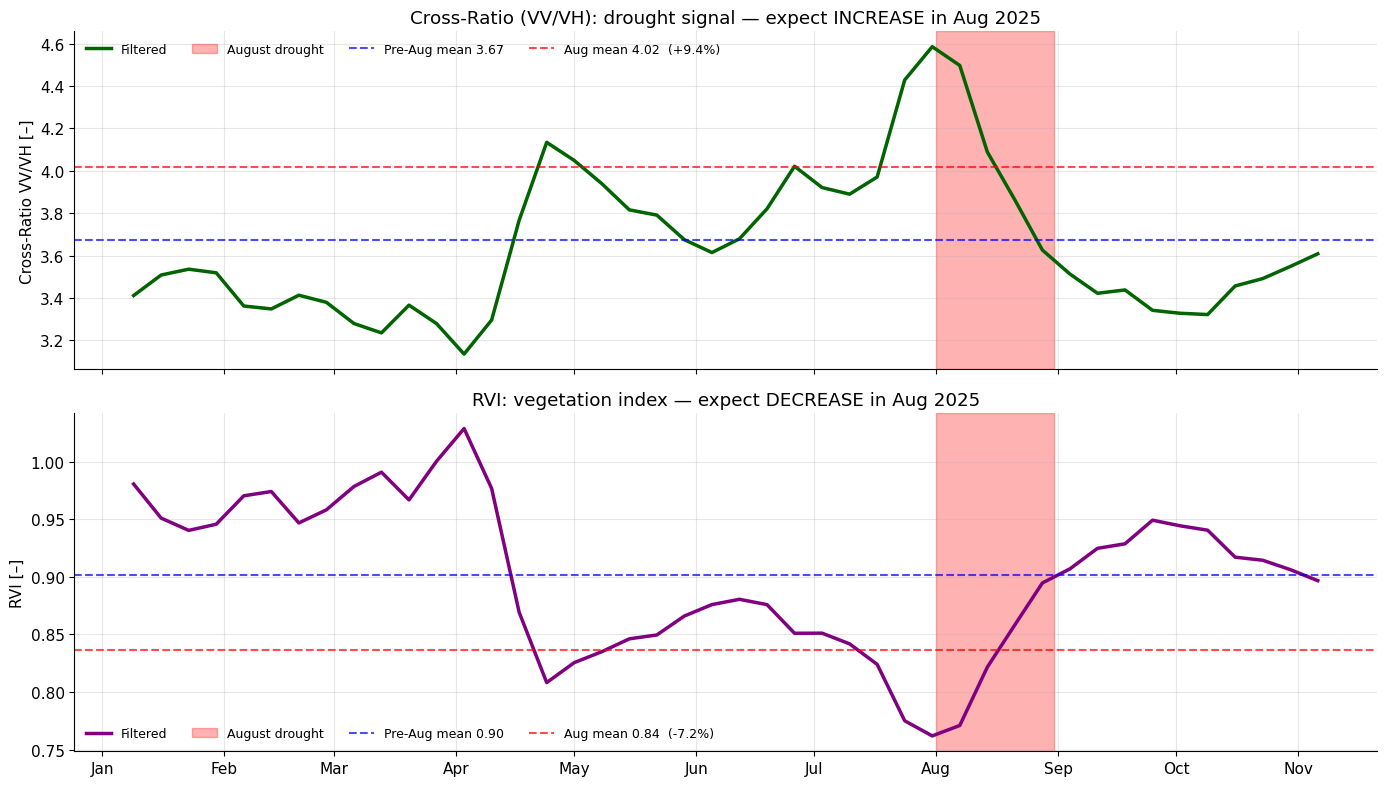

In [310]:
august_mask  = (ts_savgol.index >= '2025-08-01') & (ts_savgol.index <= '2025-08-31')
pre_aug_mask = ts_savgol.index < '2025-08-01'

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

for ax, col, ylabel, color in [
    (axes[0], 'CR',  'Cross-Ratio VV/VH [–]', 'darkgreen'),
    (axes[1], 'RVI', 'RVI [–]',               'purple'),
]:
    pre_mean = ts_savgol.loc[pre_aug_mask, col].mean()
    aug_mean = ts_savgol.loc[august_mask,  col].mean()
    change   = (aug_mean - pre_mean) / pre_mean * 100

    ax.plot(ts_savgol.index, ts_savgol[col], '-', lw=2.5, color=color, label='Filtered')
    ax.axvspan(pd.Timestamp('2025-08-01'), pd.Timestamp('2025-08-31'),
               alpha=0.3, color='red', label='August drought')
    ax.axhline(pre_mean, color='blue', ls='--', alpha=0.7,
               label=f'Pre-Aug mean {pre_mean:.2f}')
    ax.axhline(aug_mean, color='red',  ls='--', alpha=0.7,
               label=f'Aug mean {aug_mean:.2f}  ({change:+.1f}%)')
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=9, frameon=False, ncol=4)

axes[0].set_title('Cross-Ratio (VV/VH): drought signal — expect INCREASE in Aug 2025')
axes[1].set_title('RVI: vegetation index — expect DECREASE in Aug 2025')
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b'))
axes[-1].xaxis.set_major_locator(mdates.MonthLocator())
plt.tight_layout()
plt.show()

## Save filtered CSV

In [311]:
EXPORT_VARS = ['VH', 'VV', 'CR', 'Span']

# Apply SavGol to the std series with the same parameters
ts_savgol_std = ts_rolling_std.copy()
for col in EXPORT_VARS:
    valid = ~np.isnan(ts_savgol_std[col])
    if valid.sum() >= SAVGOL_WINDOW:
        ts_savgol_std.loc[valid, col] = savgol_filter(
            ts_savgol_std.loc[valid, col].values,
            window_length=SAVGOL_WINDOW,
            polyorder=SAVGOL_POLY,
        )

out = pd.concat([
    ts_rolling[EXPORT_VARS].add_suffix('_raw'),
    ts_rolling_std[EXPORT_VARS].add_suffix('_raw_std'),
    ts_savgol[EXPORT_VARS].add_suffix('_savgol'),
    ts_savgol_std[EXPORT_VARS].add_suffix('_savgol_std'),
], axis=1)

# Interleave: VH_raw, VH_raw_std, VH_savgol, VH_savgol_std, VV_raw, ...
out = out[[f'{v}_{s}' for v in EXPORT_VARS for s in ('raw', 'raw_std', 'savgol', 'savgol_std')]]
out.index.name = 'time'

OUT_CSV.parent.mkdir(parents=True, exist_ok=True)
out.to_csv(OUT_CSV, float_format='%.6f')
print(f'Saved: {OUT_CSV}  ({len(out)} rows × {len(out.columns)} cols)')
print(f'Columns: {list(out.columns)}')

Saved: /mnt/data/lk1167/projects/dehar-spac/data/processed/satellite/sentinel1_filtered_2025.csv  (44 rows × 16 cols)
Columns: ['VH_raw', 'VH_raw_std', 'VH_savgol', 'VH_savgol_std', 'VV_raw', 'VV_raw_std', 'VV_savgol', 'VV_savgol_std', 'CR_raw', 'CR_raw_std', 'CR_savgol', 'CR_savgol_std', 'Span_raw', 'Span_raw_std', 'Span_savgol', 'Span_savgol_std']


---
## Schellenberg et al. (2023) — Span Anomaly Approach

> *Potential of Sentinel-1 SAR to Assess Damage in Drought-Affected Temperate Deciduous Broadleaf Forests*  
> Schellenberg et al., Remote Sensing 2023, 15, 1004. https://doi.org/10.3390/rs15041004

### Key methodological differences from the current approach above

| Aspect | Current (reference notebook style) | Schellenberg et al. (2023) |
|---|---|---|
| **Primary indicator** | CR = VV/VH | **Span = VV+VH [dB]** |
| **Spatial filter** | Lee(3) — always | **none** — temporal-only filtering |
| **Temporal filter** | rolling(3) → SavGol(5) | rolling mean, **ENL ∈ {3, 7, 13, 19}** |
| **Optimal window** | ~3 scenes (21 days) | **ENL=13** (~80 days, raw 6-day passes) |
| **Season** | full year | **growing season only** (DOY 130–280, May–Oct) |
| **Anomaly** | none | **ΔSpan = value − growing-season mean** |
| **Reference** | none | multi-year pre-drought baseline (their study) |

### Key findings of the paper (Table 1, deciduous broadleaf forest, Hainich NP)

- **Span was the best predictor** of drought damage: ΔSpan = −0.50 ± 1.38 dB (Y₂, p < 0.0001, t = 4.42)
- **CR anomaly was not statistically significant** in any year (ΔCR ≈ −0.085 ± 1.563 in Y₂)
- RVI carries the same information as CR (confirmed by PCA) — redundant for this application
- Span anomaly appeared ~1 year after NDVI anomaly (**SAR lags optical by ~1 year**)  
  → Optics captures early chlorophyll/vitality loss; SAR captures slower structural/hydrostructural decay
- Growing season restriction is essential: removes leaf-on/off phenological confounders

### Adaptation for our single-year 2025 dataset

We have no CD−/CD0 damage classes (no ground-truth mortality map), so we replace  
the inter-class anomaly with a **temporal anomaly**: Δ = value − growing-season mean.  
This tests whether August shows a systematic departure from the seasonal baseline.

ENL= 1: Span SD (growing season) = 0.443 dB  (21 scenes)
ENL= 3: Span SD (growing season) = 0.234 dB  (21 scenes)
ENL= 7: Span SD (growing season) = 0.106 dB  (21 scenes)
ENL=13: Span SD (growing season) = 0.103 dB  (21 scenes)

Growing season: 21 scenes  (2025-05-15 – 2025-10-02)
Span reference (growing-season mean): -7.096 dB
Span anomaly — pre-August : 0.025 dB
Span anomaly — August     : -0.118 dB  (paper expects ~−0.50 dB for 2nd-year damaged canopy)


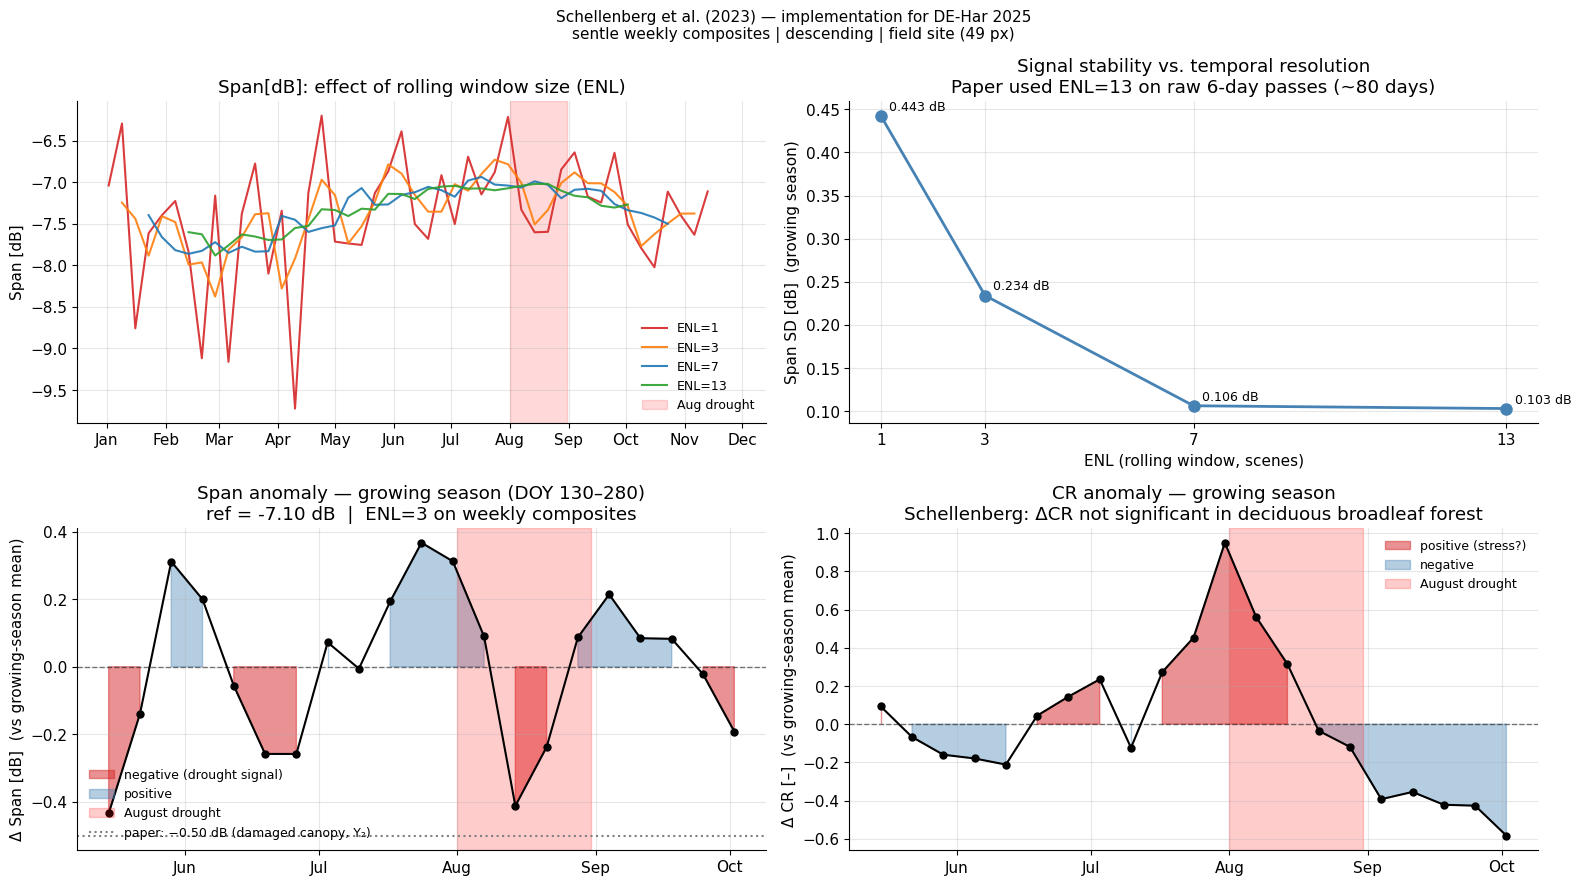

In [ ]:
# ─── Schellenberg et al. (2023) — ENL comparison + Span anomaly ─────────────
# Starting from Lee-filtered site data (vh_spatial, vv_spatial).
# sentle data are already weekly composites (~2-3 passes averaged per scene),
# so each point already has some inherent speckle reduction.
# ENL here refers to additional rolling applied on top of that.

ENL_WINDOWS  = [1, 3, 7, 13]   # rolling window sizes tested in the paper
GS_DOY_START = 130              # ~10 May  (Schellenberg leaf-flush threshold)
GS_DOY_END   = 280              # ~7 Oct   (Schellenberg leaf-fall threshold)


def gs_mask(index):
    """Boolean array: True for dates within growing season DOY range."""
    doys = index.day_of_year
    return (doys >= GS_DOY_START) & (doys <= GS_DOY_END)


# ── 1: Build Span[dB] time series for each ENL ────────────────────────────────
enl_span_db = {}
for enl in ENL_WINDOWS:
    if enl == 1:
        vh_e, vv_e = vh_spatial, vv_spatial
    else:
        vh_e = vh_spatial.rolling(time=enl, center=True).mean().dropna(dim='time')
        vv_e = vv_spatial.rolling(time=enl, center=True).mean().dropna(dim='time')
    t_e = pd.to_datetime(vh_e.time.values)
    enl_span_db[enl] = pd.Series(
        lin2db((vh_e + vv_e).mean(dim=['x', 'y']).values), index=t_e
    )
    
# -- 2: Build CR and RVI time series for for each ENL (for comparison with paper's finding on CR)
    cr_e  = vv_e / (vh_e + 1e-30)
    rvi_e = 4 * vh_e / (vv_e + vh_e + 1e-30)
    enl_span_db[enl+'_CR']  = pd.Series(
        cr_e.mean(dim=['x', 'y']).values, index=t_e
    )
    enl_span_db[enl+'_RVI'] = pd.Series(
        rvi_e.mean(dim=['x', 'y']).values, index=t_e
    ) 

# Signal stability: SD of Span within growing season per ENL
gs_sds = {}
for enl, s in enl_span_db.items():
    gs_e = s[gs_mask(s.index)]
    gs_sds[enl] = float(gs_e.std())
    print(f'ENL={enl:2d}: Span SD (growing season) = {gs_sds[enl]:.3f} dB  ({len(gs_e)} scenes)')

# ── 2: Span temporal anomaly — growing season, ENL=3 ──────────────────────────
# ENL=3 on weekly composites ≈ 21-day window; comparable to paper's ENL=13
# on raw 6-day passes in terms of calendar days (~78 vs ~21 days).
# Weekly composites already aggregate ENL ≈ 2–3, so effective ENL ≈ 6–9.
span_s3   = enl_span_db[3]
span_gs   = span_s3[gs_mask(span_s3.index)]
span_ref  = float(span_gs.mean())
span_anom = span_gs - span_ref   # temporal anomaly [dB]

# Get C
gs_sav     = gs_mask(ts_savgol.index)
cr_ref     = float(ts_savgol.loc[gs_sav, 'CR'].mean())
cr_anom_gs = ts_savgol.loc[gs_sav, 'CR'] - cr_ref

# RVI anomaly — growing season (for completeness, not in paper)
rvi_ref     = float(ts_savgol.loc[gs_sav, 'RVI'].mean())
rvi_anom_gs = ts_savgol.loc[gs_sav, 'RVI'] - rvi_ref

pre_gs = span_anom.index < '2025-08-01'
aug_gs = (span_anom.index >= '2025-08-01') & (span_anom.index <= '2025-08-31')
print(f'\nGrowing season: {gs_mask(span_s3.index).sum()} scenes  '
      f'({span_gs.index[0].date()} – {span_gs.index[-1].date()})')
print(f'Span reference (growing-season mean): {span_ref:.3f} dB')
print(f'Span anomaly — pre-August : {span_anom[pre_gs].mean():.3f} dB')
if aug_gs.any():
    print(f'Span anomaly — August     : {span_anom[aug_gs].mean():.3f} dB  '
          f'(paper expects ~−0.50 dB for 2nd-year damaged canopy)')

# ── 3: 4-panel plot ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 9))

# Top-left: Span[dB] time series for each ENL
colors_enl = ['#d62728', '#ff7f0e', '#1f77b4', '#2ca02c']
for (enl, s), c in zip(enl_span_db.items(), colors_enl):
    axes[0, 0].plot(s.index, s.values, '-', lw=1.5, color=c, alpha=0.9, label=f'ENL={enl}')
axes[0, 0].axvspan(pd.Timestamp('2025-08-01'), pd.Timestamp('2025-08-31'),
                    alpha=0.15, color='red', label='Aug drought')
axes[0, 0].set_ylabel('Span [dB]')
axes[0, 0].set_title('Span[dB]: effect of rolling window size (ENL)')
axes[0, 0].legend(fontsize=9, frameon=False)
axes[0, 0].xaxis.set_major_formatter(mdates.DateFormatter('%b'))
axes[0, 0].xaxis.set_major_locator(mdates.MonthLocator())
axes[0, 0].grid(True, alpha=0.3)

# Top-right: SD vs ENL (signal stability trade-off)
axes[0, 1].plot(ENL_WINDOWS, [gs_sds[e] for e in ENL_WINDOWS],
                'o-', color='steelblue', ms=8, lw=2)
for enl in ENL_WINDOWS:
    axes[0, 1].annotate(f'{gs_sds[enl]:.3f} dB', (enl, gs_sds[enl]),
                        textcoords='offset points', xytext=(6, 4), fontsize=9)
axes[0, 1].set_xlabel('ENL (rolling window, scenes)')
axes[0, 1].set_ylabel('Span SD [dB]  (growing season)')
axes[0, 1].set_title('Signal stability vs. temporal resolution\n'
                      'Paper used ENL=13 on raw 6-day passes (~80 days)')
axes[0, 1].set_xticks(ENL_WINDOWS)
axes[0, 1].grid(True, alpha=0.3)

# Bottom-left: Span anomaly — Schellenberg's primary indicator
axes[1, 0].axhline(0, color='black', lw=1, ls='--', alpha=0.5)
axes[1, 0].fill_between(span_anom.index, span_anom.values, 0,
                         where=span_anom.values < 0, color='#d62728', alpha=0.5,
                         label='negative (drought signal)')
axes[1, 0].fill_between(span_anom.index, span_anom.values, 0,
                         where=span_anom.values >= 0, color='steelblue', alpha=0.4,
                         label='positive')
axes[1, 0].plot(span_anom.index, span_anom.values, 'o-', color='black', ms=5, lw=1.5)
axes[1, 0].axvspan(pd.Timestamp('2025-08-01'), pd.Timestamp('2025-08-31'),
                    alpha=0.2, color='red', label='August drought')
axes[1, 0].axhline(-0.5, color='gray', ls=':', lw=1.5,
                    label='paper: −0.50 dB (damaged canopy, Y₂)')
axes[1, 0].set_ylabel('Δ Span [dB]  (vs growing-season mean)')
axes[1, 0].set_title(f'Span anomaly — growing season (DOY {GS_DOY_START}–{GS_DOY_END})\n'
                      f'ref = {span_ref:.2f} dB  |  ENL=3 on weekly composites')
axes[1, 0].legend(fontsize=9, frameon=False)
axes[1, 0].xaxis.set_major_formatter(mdates.DateFormatter('%b'))
axes[1, 0].xaxis.set_major_locator(mdates.MonthLocator())
axes[1, 0].grid(True, alpha=0.3)

# Bottom-right: CR anomaly — paper's finding: not significant in DBF
axes[1, 1].axhline(0, color='black', lw=1, ls='--', alpha=0.5)
axes[1, 1].fill_between(cr_anom_gs.index, cr_anom_gs.values, 0,
                         where=cr_anom_gs.values > 0, color='#d62728', alpha=0.5,
                         label='positive (stress?)')
axes[1, 1].fill_between(cr_anom_gs.index, cr_anom_gs.values, 0,
                         where=cr_anom_gs.values <= 0, color='steelblue', alpha=0.4,
                         label='negative')
axes[1, 1].plot(cr_anom_gs.index, cr_anom_gs.values, 'o-', color='black', ms=5, lw=1.5)
axes[1, 1].axvspan(pd.Timestamp('2025-08-01'), pd.Timestamp('2025-08-31'),
                    alpha=0.2, color='red', label='August drought')
axes[1, 1].set_ylabel('Δ CR [–]  (vs growing-season mean)')
axes[1, 1].set_title('CR anomaly — growing season\n'
                      'Schellenberg: ΔCR not significant in deciduous broadleaf forest')
axes[1, 1].legend(fontsize=9, frameon=False)
axes[1, 1].xaxis.set_major_formatter(mdates.DateFormatter('%b'))
axes[1, 1].xaxis.set_major_locator(mdates.MonthLocator())
axes[1, 1].grid(True, alpha=0.3)

fig.suptitle('Schellenberg et al. (2023) — implementation for DE-Har 2025\n'
             'sentle weekly composites | descending | field site (49 px)', fontsize=11)
plt.tight_layout()
plt.show()

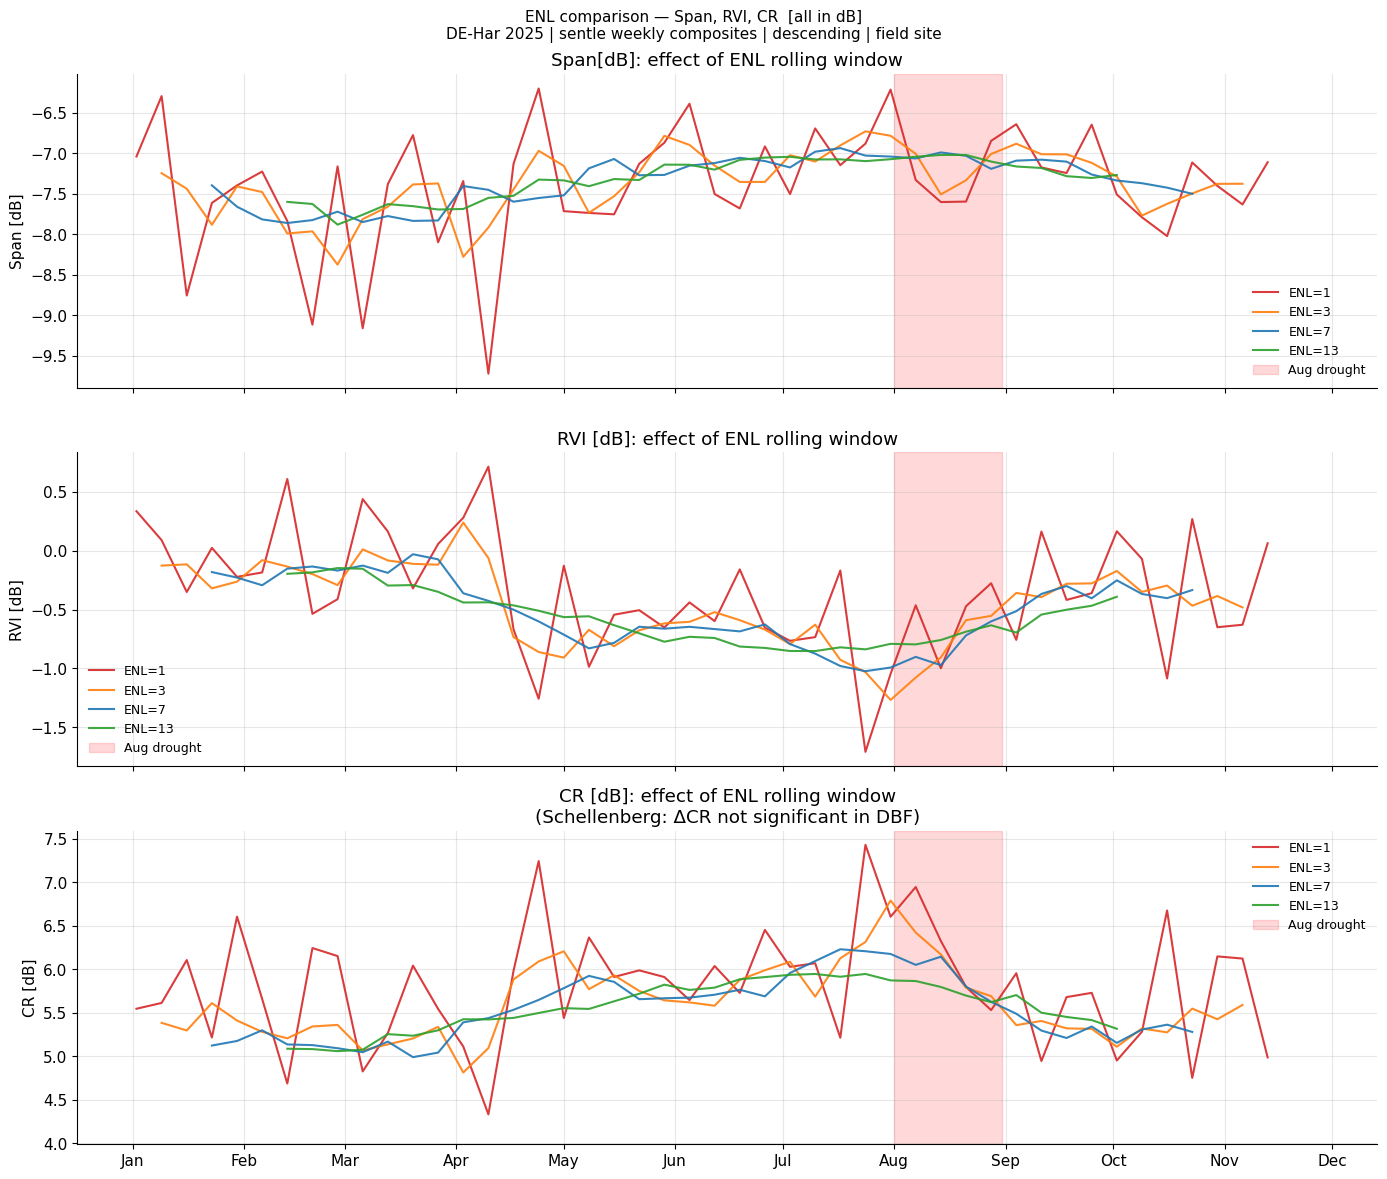

In [221]:
# ─── 3-panel ENL comparison: Span [dB], RVI [dB], CR [dB] ───────────────────
colors_enl = ['#d62728', '#ff7f0e', '#1f77b4', '#2ca02c']

enl_series = {}   # keyed by (enl, variable)
for enl in ENL_WINDOWS:
    if enl == 1:
        vh_e, vv_e = vh_spatial, vv_spatial
    else:
        vh_e = vh_spatial.rolling(time=enl, center=True).mean().dropna(dim='time')
        vv_e = vv_spatial.rolling(time=enl, center=True).mean().dropna(dim='time')
    t_e = pd.to_datetime(vh_e.time.values)
    enl_series[(enl, 'Span')] = pd.Series(
        lin2db((vh_e + vv_e).mean(dim=['x', 'y']).values), index=t_e
    )
    enl_series[(enl, 'CR')] = pd.Series(
        lin2db((vv_e / (vh_e + 1e-30)).mean(dim=['x', 'y']).values), index=t_e
    )
    enl_series[(enl, 'RVI')] = pd.Series(
        lin2db((4 * vh_e / (vv_e + vh_e + 1e-30)).mean(dim=['x', 'y']).values), index=t_e
    )

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

panels = [
    ('Span', 'Span [dB]',      'Span[dB]: effect of ENL rolling window'),
    ('RVI',  'RVI [dB]',       'RVI [dB]: effect of ENL rolling window'),
    ('CR',   'CR [dB]',        'CR [dB]: effect of ENL rolling window\n'
                                '(Schellenberg: ΔCR not significant in DBF)'),
]

for ax, (var, ylabel, title) in zip(axes, panels):
    for enl, c in zip(ENL_WINDOWS, colors_enl):
        s = enl_series[(enl, var)]
        ax.plot(s.index, s.values, '-', lw=1.5, color=c, alpha=0.9, label=f'ENL={enl}')
    ax.axvspan(pd.Timestamp('2025-08-01'), pd.Timestamp('2025-08-31'),
               alpha=0.15, color='red', label='Aug drought')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(fontsize=9, frameon=False)
    ax.grid(True, alpha=0.3)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b'))
axes[-1].xaxis.set_major_locator(mdates.MonthLocator())
fig.suptitle('ENL comparison — Span, RVI, CR  [all in dB]\n'
             'DE-Har 2025 | sentle weekly composites | descending | field site',
             fontsize=11)
plt.tight_layout()
plt.show()

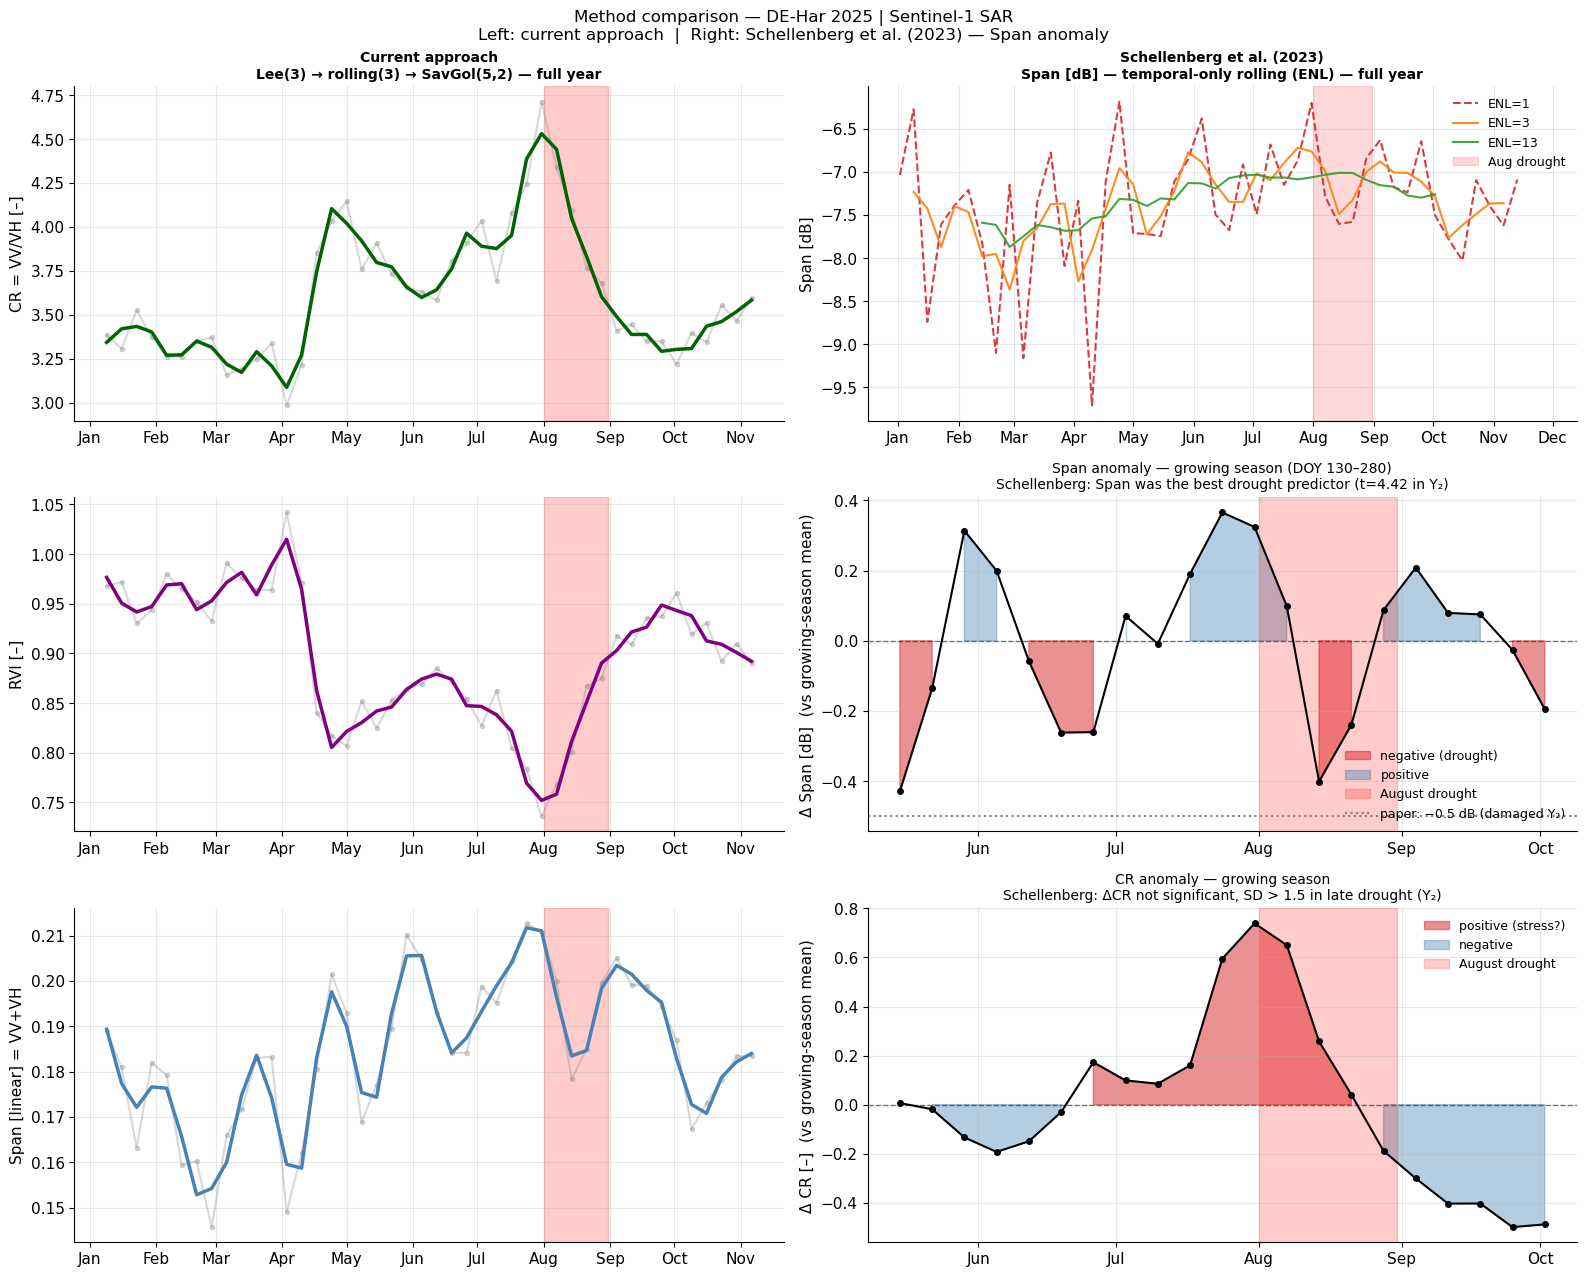

=== Schellenberg et al. (2023) — key results for context ===
Table 1, Y₂ (2020, 2nd year after drought onset):
  ΔSpan = −0.50 ± 1.38 dB  [significant, p < 0.0001, t = 4.42]
  ΔCR   = −0.085 ± 1.563   [NOT significant]
  ΔRVI  not in Table 1 (CR and RVI carry same information per PCA)

=== Our site DE-Har 2025 (temporal anomaly approach) ===
  Δ Span August = -0.114 dB  (paper: ~−0.50 dB for 2nd-year drought damage)
  Δ CR   August = 0.190    (paper: ~−0.085, not significant)

Note: Schellenberg used raw 6-day S-1 passes; our data are sentle weekly composites.
ENL comparisons are approximate: weekly composite ≈ 2–3 passes per scene already.


In [175]:
# ─── Side-by-side method comparison ─────────────────────────────────────────
fig, axes = plt.subplots(3, 2, figsize=(16, 13))
DROUGHT = (pd.Timestamp('2025-08-01'), pd.Timestamp('2025-08-31'))

# ── Left column: current approach (Lee → rolling → SavGol, full year) ─────────
for ax, col, ylabel, color in [
    (axes[0, 0], 'CR',   'CR = VV/VH [–]',        'darkgreen'),
    (axes[1, 0], 'RVI',  'RVI [–]',                'purple'),
    (axes[2, 0], 'Span', 'Span [linear] = VV+VH',  'steelblue'),
]:
    ax.plot(ts_rolling.index, ts_rolling[col], 'o-', color='gray', alpha=0.3, ms=3)
    ax.plot(ts_savgol.index,  ts_savgol[col],  '-',  color=color,  lw=2.5)
    ax.axvspan(*DROUGHT, alpha=0.2, color='red')
    ax.set_ylabel(ylabel)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.grid(True, alpha=0.3)

axes[0, 0].set_title('Current approach\nLee(3) → rolling(3) → SavGol(5,2) — full year',
                      fontsize=10, fontweight='bold')

# ── Right column: Schellenberg approach ───────────────────────────────────────
# Top: Span[dB] full year, ENL=1/3/13
for enl, c, ls in [(1, '#d62728', '--'), (3, '#ff7f0e', '-'), (13, '#2ca02c', '-')]:
    axes[0, 1].plot(enl_span_db[enl].index, enl_span_db[enl].values,
                    ls, lw=1.5, color=c, alpha=0.9, label=f'ENL={enl}')
axes[0, 1].axvspan(*DROUGHT, alpha=0.15, color='red', label='Aug drought')
axes[0, 1].set_ylabel('Span [dB]')
axes[0, 1].set_title('Schellenberg et al. (2023)\nSpan [dB] — temporal-only rolling (ENL) — full year',
                      fontsize=10, fontweight='bold')
axes[0, 1].legend(fontsize=9, frameon=False)
axes[0, 1].xaxis.set_major_formatter(mdates.DateFormatter('%b'))
axes[0, 1].xaxis.set_major_locator(mdates.MonthLocator())
axes[0, 1].grid(True, alpha=0.3)

# Middle: Span anomaly — growing season
axes[1, 1].axhline(0, color='black', lw=1, ls='--', alpha=0.5)
axes[1, 1].fill_between(span_anom.index, span_anom.values, 0,
                         where=span_anom.values < 0, color='#d62728', alpha=0.5, label='negative (drought)')
axes[1, 1].fill_between(span_anom.index, span_anom.values, 0,
                         where=span_anom.values >= 0, color='steelblue', alpha=0.4, label='positive')
axes[1, 1].plot(span_anom.index, span_anom.values, 'o-', color='black', ms=4, lw=1.5)
axes[1, 1].axvspan(*DROUGHT, alpha=0.2, color='red', label='August drought')
axes[1, 1].axhline(-0.5, color='gray', ls=':', lw=1.5, label='paper: −0.5 dB (damaged Y₂)')
axes[1, 1].set_ylabel('Δ Span [dB]  (vs growing-season mean)')
axes[1, 1].set_title(f'Span anomaly — growing season (DOY {GS_DOY_START}–{GS_DOY_END})\n'
                      f'Schellenberg: Span was the best drought predictor (t=4.42 in Y₂)',
                      fontsize=10)
axes[1, 1].legend(fontsize=9, frameon=False)
axes[1, 1].xaxis.set_major_formatter(mdates.DateFormatter('%b'))
axes[1, 1].xaxis.set_major_locator(mdates.MonthLocator())
axes[1, 1].grid(True, alpha=0.3)

# Bottom: CR anomaly — growing season (paper: limited / not significant)
axes[2, 1].axhline(0, color='black', lw=1, ls='--', alpha=0.5)
axes[2, 1].fill_between(cr_anom_gs.index, cr_anom_gs.values, 0,
                         where=cr_anom_gs.values > 0, color='#d62728', alpha=0.5, label='positive (stress?)')
axes[2, 1].fill_between(cr_anom_gs.index, cr_anom_gs.values, 0,
                         where=cr_anom_gs.values <= 0, color='steelblue', alpha=0.4, label='negative')
axes[2, 1].plot(cr_anom_gs.index, cr_anom_gs.values, 'o-', color='black', ms=4, lw=1.5)
axes[2, 1].axvspan(*DROUGHT, alpha=0.2, color='red', label='August drought')
axes[2, 1].set_ylabel('Δ CR [–]  (vs growing-season mean)')
axes[2, 1].set_title('CR anomaly — growing season\n'
                      'Schellenberg: ΔCR not significant, SD > 1.5 in late drought (Y₂)',
                      fontsize=10)
axes[2, 1].legend(fontsize=9, frameon=False)
axes[2, 1].xaxis.set_major_formatter(mdates.DateFormatter('%b'))
axes[2, 1].xaxis.set_major_locator(mdates.MonthLocator())
axes[2, 1].grid(True, alpha=0.3)

fig.suptitle('Method comparison — DE-Har 2025 | Sentinel-1 SAR\n'
             'Left: current approach  |  Right: Schellenberg et al. (2023) — Span anomaly',
             fontsize=12)
plt.tight_layout()
plt.show()

# ── Summary ───────────────────────────────────────────────────────────────────
print('=== Schellenberg et al. (2023) — key results for context ===')
print('Table 1, Y₂ (2020, 2nd year after drought onset):')
print('  ΔSpan = −0.50 ± 1.38 dB  [significant, p < 0.0001, t = 4.42]')
print('  ΔCR   = −0.085 ± 1.563   [NOT significant]')
print('  ΔRVI  not in Table 1 (CR and RVI carry same information per PCA)')
print()
print('=== Our site DE-Har 2025 (temporal anomaly approach) ===')
aug_gs = (span_anom.index >= '2025-08-01') & (span_anom.index <= '2025-08-31')
aug_cr = (cr_anom_gs.index >= '2025-08-01') & (cr_anom_gs.index <= '2025-08-31')
if aug_gs.any():
    print(f'  Δ Span August = {span_anom[aug_gs].mean():.3f} dB  '
          f'(paper: ~−0.50 dB for 2nd-year drought damage)')
if aug_cr.any():
    print(f'  Δ CR   August = {cr_anom_gs[aug_cr].mean():.3f}    '
          f'(paper: ~−0.085, not significant)')
print()
print('Note: Schellenberg used raw 6-day S-1 passes; our data are sentle weekly composites.')
print('ENL comparisons are approximate: weekly composite ≈ 2–3 passes per scene already.')